In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge 
from sklearn.preprocessing import StandardScaler, PolynomialFeatures 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error 

import tensorflow as tf 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense 
from tensorflow.keras.activations import relu, linear
from tensorflow.keras.losses import SparseCategoricalCrossentropy 
from tensorflow.keras.optimizers import Adam 

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

tf.keras.backend.set_floatx('float64')

tf.autograph.set_verbosity(0)

In [3]:
def gen_data(m, seed = 1, scale = 0.7): 
    c= 0
    x_train = np.linspace(0, 49, m) 
    np.random.seed(seed) 
    y_ideal = x_train**2 + c
    y_train = y_ideal + scale * y_ideal * (np.random.sample((m, ))-0.5)
    x_ideal = x_train 
    return x_train, y_train, x_ideal, y_ideal 

In [5]:
X, y, x_ideal, y_ideal = gen_data(18, 2, 0.7) 
print("X.shape", X.shape, "y.shape", y.shape) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 1)
print("X_train.shape", X_train.shape, "y_train.shape", y_train.shape)
print("X_test.shape", X_test.shape, "y_test.shape", y_test.shape)

X.shape (18,) y.shape (18,)
X_train.shape (12,) y_train.shape (12,)
X_test.shape (6,) y_test.shape (6,)


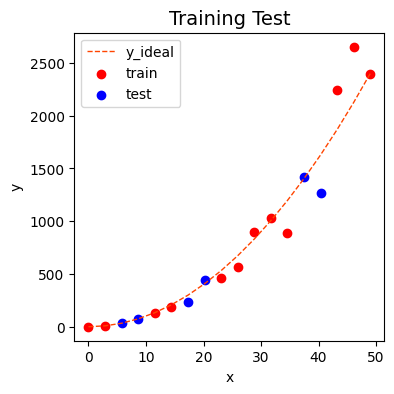

In [6]:
fig, ax = plt.subplots(1,1 , figsize = (4, 4)) 
ax.plot(x_ideal, y_ideal, "--", color = "orangered", label = "y_ideal", lw = 1) 
ax.set_title("Training Test", fontsize = 14) 
ax.set_xlabel("x") 
ax.set_ylabel("y") 

ax.scatter(X_train, y_train, color = "red", label = "train") 
ax.scatter(X_test, y_test, color = "blue" , label = "test") 
ax.legend(loc = "upper left") 
plt.show()

<a name="2.2"></a>
### 2.2 Error calculation for model evaluation, linear regression
When *evaluating* a linear regression model, you average the squared error difference of the predicted values and the target values.

$$ J_\text{test}(\mathbf{w},b) = 
            \frac{1}{2m_\text{test}}\sum_{i=0}^{m_\text{test}-1} ( f_{\mathbf{w},b}(\mathbf{x}^{(i)}_\text{test}) - y^{(i)}_\text{test} )^2 
            \tag{1}
$$

In [7]:
def eval_mse(y, yhat): 
    m = len(y) 
    mse = (y - yhat)**2 / (2*m) 
    err = np.sum(mse) 
    return err

In [11]:
y_hat = np.array([2.4, 4.2])
y_tmp = np.array([2.3, 4.1])
err = eval_mse(y_hat, y_tmp)
print(err)

0.0050000000000000305


<a name="2.3"></a>
### 2.3 Compare performance on training and test data
Let's build a high degree polynomial model to minimize training error. This will use the linear_regression functions from `sklearn`. The code is in the imported utility file if you would like to see the details. The steps below are:
* create and fit the model. ('fit' is another name for training or running gradient descent).
* compute the error on the training data.
* compute the error on the test data.

In [15]:
class lin_model: 
    def __init__ (self, degree, regularization = False, lambda_ = 0): 
        if regularization: 
            self.linear_model = Ridge(alpha = lambda_) 
        else: 
            self.linear_model = LinearRegression()
        self.poly = PolynomialFeatures(degree, include_bias = False) 
        self.scaler = StandardScaler()

    def fit(self, X_train, y_train): 
        X_train_mapped = self.poly.fit_transform(X_train.reshape(-1, 1)) 
        X_train_mapped_scaled = self.scaler.fit_transform(X_train_mapped) 
        self.linear_model.fit(X_train_mapped_scaled, y_train)

    def predict(self, X): 
        X_mapped = self.poly.transform(X.reshape(-1, 1)) 
        X_mapped_scaled = self.scaler.transform(X_mapped) 
        yhat = self.linear_model.predict(X_mapped_scaled) 
        return (yhat) 

    def mse(self, y, yhat): 
        err = mean_squared_error(y, yhat) / 2
        return err

In [16]:
degree = 10
lmodel = lin_model(degree)
lmodel.fit(X_train, y_train) 

yhat = lmodel.predict(X_train) 
err_train = lmodel.mse(y_train, yhat) 

yhat = lmodel.predict(X_test) 
err_test = lmodel.mse(y_test, yhat)

In [17]:
print(f"training err {err_train:0.2f}, test err {err_test:0.2f}")

training err 58.01, test err 171215.01


In [18]:
X, y, x_ideal, y_ideal = gen_data(40, 5, 0.7)
print("X.shape", X.shape, "y.shape", y.shape) 

X_train, X_, y_train, y_ = train_test_split(X, y, test_size = 0.4, random_state = 1) 
X_cv, X_test, y_cv, y_test = train_test_split(X_, y_, test_size = 0.5, random_state = 1)
print("X_train.shape", X_train.shape, "y_train.shape", y_train.shape)
print("X_cv.shape", X_cv.shape, "y_cv.shape", y_cv.shape)
print("X_test.shape", X_test.shape, "y_test.shape", y_test.shape)

X.shape (40,) y.shape (40,)
X_train.shape (24,) y_train.shape (24,)
X_cv.shape (8,) y_cv.shape (8,)
X_test.shape (8,) y_test.shape (8,)


In [20]:
max_degree = 9
err_train = np.zeros(max_degree)    
err_cv = np.zeros(max_degree)      
x = np.linspace(0,int(X.max()),100)  
y_pred = np.zeros((100,max_degree))  #columns are lines to plot

for degree in range(max_degree):
    lmodel = lin_model(degree+1)
    lmodel.fit(X_train, y_train)
    yhat = lmodel.predict(X_train)
    err_train[degree] = lmodel.mse(y_train, yhat)
    yhat = lmodel.predict(X_cv)
    err_cv[degree] = lmodel.mse(y_cv, yhat)
    y_pred[:,degree] = lmodel.predict(x)
    
optimal_degree = np.argmin(err_cv)+1

In [21]:
lambda_range = np.array([0.0, 1e-6, 1e-5, 1e-4,1e-3,1e-2, 1e-1,1,10,100])
num_steps = len(lambda_range)
degree = 10
err_train = np.zeros(num_steps)    
err_cv = np.zeros(num_steps)       
x = np.linspace(0,int(X.max()),100) 
y_pred = np.zeros((100,num_steps))  #columns are lines to plot

for i in range(num_steps):
    lambda_= lambda_range[i]
    lmodel = lin_model(degree, regularization=True, lambda_=lambda_)
    lmodel.fit(X_train, y_train)
    yhat = lmodel.predict(X_train)
    err_train[i] = lmodel.mse(y_train, yhat)
    yhat = lmodel.predict(X_cv)
    err_cv[i] = lmodel.mse(y_cv, yhat)
    y_pred[:,i] = lmodel.predict(x)
    
optimal_reg_idx = np.argmin(err_cv) 